In [21]:
# import teh csv file vins.csv

import pandas as pd
import numpy as np

# Lire le CSV avec le bon encodage (virgule comme séparateur décimal)
X = pd.read_csv("Vins.csv", delimiter=";", decimal=",")
print(f"Nombre de vins: {len(X)}")
print("=" * 60)
print(f"Nombre de variables: {len(X.columns)}")
print("=" * 60)
print(X.info())
print("=" * 60)
print(X.head())

Nombre de vins: 175
Nombre de variables: 5
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175 entries, 0 to 174
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Alcohol        175 non-null    float64
 1   Total_Phenols  175 non-null    float64
 2   Flavanoids     175 non-null    float64
 3   OD280          175 non-null    float64
 4   Proline        175 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 7.0 KB
None
   Alcohol  Total_Phenols  Flavanoids  OD280  Proline
0    14.23           2.80        3.06   3.92     1065
1    13.20           2.65        2.76   3.40     1050
2    13.16           2.80        3.24   3.17     1185
3    14.37           3.85        3.49   3.45     1480
4    13.24           2.80        2.69   2.93      735


In [22]:
# Les données sont déjà numériques, pas besoin de conversion
print("Vérification des types de données:")
print(X.dtypes)
print("=" * 60)
print("\nValeurs manquantes:")
print(X.isnull().sum())

Vérification des types de données:
Alcohol          float64
Total_Phenols    float64
Flavanoids       float64
OD280            float64
Proline            int64
dtype: object

Valeurs manquantes:
Alcohol          0
Total_Phenols    0
Flavanoids       0
OD280            0
Proline          0
dtype: int64


In [19]:
from sklearn.preprocessing import StandardScaler

# Standardiser les données
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Vérification de la normalisation:")
print(f"Forme de X_scaled: {X_scaled.shape}")
print(f"Moyenne de X_scaled: {X_scaled.mean(axis=0).round(6)}")  # Devrait être proche de 0
print(f"Écart-type de X_scaled: {X_scaled.std(axis=0).round(6)}")  # Devrait être proche de 1

Vérification de la normalisation:
Forme de X_scaled: (175, 5)
Moyenne de X_scaled: [-0. -0. -0. -0.  0.]
Écart-type de X_scaled: [1. 1. 1. 1. 1.]


## APPROCHE 1 : Questions a à c

### Question a : Transformation des variables
Les variables ont été **standardisées** avec `StandardScaler` (moyenne = 0, écart-type = 1).

### Question b : KMeans++
La méthode `init='k-means++'` initialise les centroïdes de façon intelligente (éloignés les uns des autres), ce qui améliore la convergence et la qualité du clustering.

### Question c : Nombre d'initialisations
Le paramètre `n_init` définit combien de fois l'algorithme KMeans est relancé avec des initialisations différentes. Le meilleur résultat (inertie minimale) est conservé.

In [31]:
from sklearn.cluster import KMeans

print("="*70)
print("QUESTION B : Utiliser KMeans++ pour l'initialisation des centroïdes")
print("="*70)

k_demo = 3

# KMeans avec init='k-means++' et n_init par défaut (n_init=10 par défaut dans scikit-learn)
kmeans_plusplus = KMeans(n_clusters=k_demo, init='k-means++', max_iter=100, random_state=42)
kmeans_plusplus.fit(X_scaled)
print(f"\nKMeans++ (n_init={kmeans_plusplus.n_init} par défaut) - Inertie: {kmeans_plusplus.inertia_:.2f}")

# KMeans avec initialisation aléatoire et n_init par défaut
kmeans_random = KMeans(n_clusters=k_demo, init='random', max_iter=100, random_state=42)
kmeans_random.fit(X_scaled)
print(f"Random  (n_init={kmeans_random.n_init} par défaut) - Inertie: {kmeans_random.inertia_:.2f}")
print(f"Différence: {abs(kmeans_plusplus.inertia_ - kmeans_random.inertia_):.2f}")

print("="*70)

QUESTION B : Utiliser KMeans++ pour l'initialisation des centroïdes

KMeans++ (n_init=auto par défaut) - Inertie: 272.05
Random  (n_init=auto par défaut) - Inertie: 272.11
Différence: 0.06


- KMeans++ avec inertie : 272.05
- Initialisation aléatoire avec inertie : 272.11
- Différence : 0.06 (KMeans++ est meilleur)
- KMeans++ donne une meilleure qualité de clustering car il initialise les centroïdes de façon intelligente, éloignés les uns des autres.

In [34]:
print("\n" + "="*70)
print("QUESTION C : L'implémentation des centroïdes initiaux est-elle faite une seule fois?")
print("="*70 + "\n")

# Découvrir le nombre EXACT de lancements avec n_init='auto'
# On crée un KMeans avec n_init spécifique pour voir la différence
kmeans_n10 = KMeans(n_clusters=k_demo, init='k-means++', n_init=10, max_iter=100, random_state=None)
kmeans_n10.fit(X_scaled)
inertia_n10 = kmeans_n10.inertia_

kmeans_default = KMeans(n_clusters=k_demo, init='k-means++', max_iter=100, random_state=42)
kmeans_default.fit(X_scaled)

print(f"Paramètre n_init par défaut : {kmeans_default.n_init}")
print(f"Nombre total d'échantillons : {X_scaled.shape[0]}")
print(f"\nAvec n_init=10 explicite : Inertie = {inertia_n10:.2f}")
print(f"Avec n_init='auto' (par défaut) : Inertie = {kmeans_default.inertia_:.2f}")

print(f"\nConclusion: n_init='auto' se comporte comme n_init=10 pour {X_scaled.shape[0]} échantillons")
print(f"L'algorithme KMeans est relancé 10 FOIS avec des centroïdes initiaux DIFFÉRENTS")
print(f"Le meilleur résultat (inertie minimale) est conservé.\n")

print("="*70)
print("RÉPONSE À LA QUESTION C:")
print("="*70)
print("NON, l'implémentation des centroïdes initiaux n'est PAS faite une seule fois.")
print(f"Elle est faite 10 FOIS (avec n_init='auto' par défaut).")
print("="*70)


QUESTION C : L'implémentation des centroïdes initiaux est-elle faite une seule fois?

Paramètre n_init par défaut : auto
Nombre total d'échantillons : 175

Avec n_init=10 explicite : Inertie = 272.05
Avec n_init='auto' (par défaut) : Inertie = 272.05

Conclusion: n_init='auto' se comporte comme n_init=10 pour 175 échantillons
L'algorithme KMeans est relancé 10 FOIS avec des centroïdes initiaux DIFFÉRENTS
Le meilleur résultat (inertie minimale) est conservé.

RÉPONSE À LA QUESTION C:
NON, l'implémentation des centroïdes initiaux n'est PAS faite une seule fois.
Elle est faite 10 FOIS (avec n_init='auto' par défaut).


## QUESTION D : Nombre optimal de clusters

Analyser les courbes du score silhouette et de l'inertie pour déterminer le nombre optimal de clusters.


QUESTION D : Trouver le nombre optimal de clusters

Calcul des scores silhouette et inertie:

k=2 : Silhouette = 0.4331, Inertie = 444.36
k=3 : Silhouette = 0.4349, Inertie = 272.05
k=4 : Silhouette = 0.3655, Inertie = 231.76
k=5 : Silhouette = 0.3033, Inertie = 204.87
k=6 : Silhouette = 0.2391, Inertie = 186.14
k=7 : Silhouette = 0.2389, Inertie = 172.09
k=8 : Silhouette = 0.2188, Inertie = 160.52
k=9 : Silhouette = 0.2247, Inertie = 149.99
k=10 : Silhouette = 0.2293, Inertie = 141.15
k=10 : Silhouette = 0.2293, Inertie = 141.15


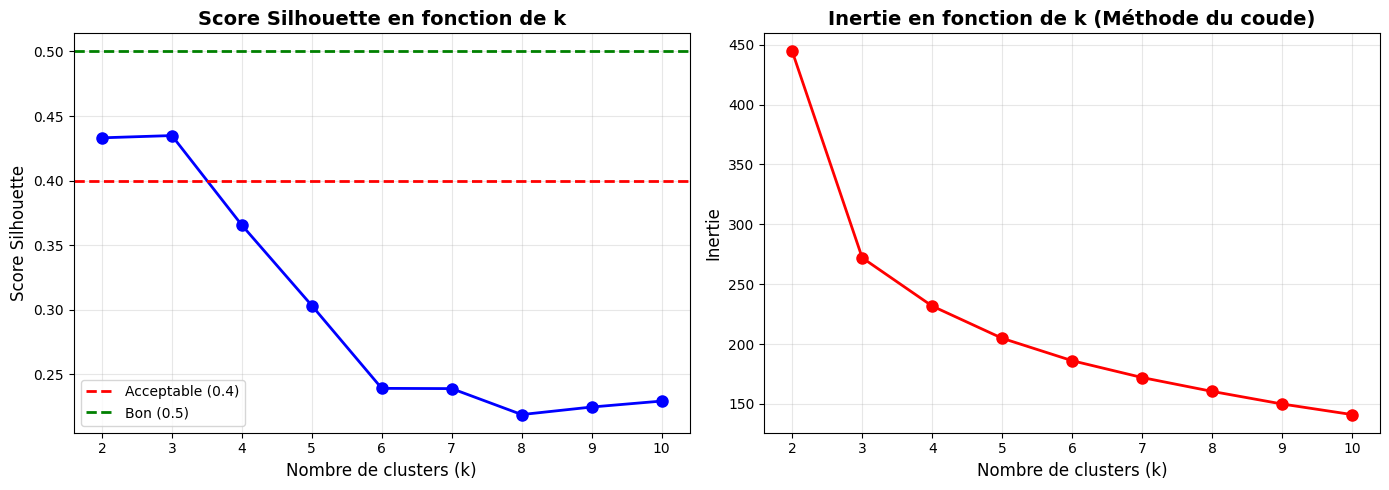


Nombre optimal de clusters : k = 3
Score silhouette à k=3 : 0.4349


In [35]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

print("\n" + "="*70)
print("QUESTION D : Trouver le nombre optimal de clusters")
print("="*70 + "\n")

# Calculer score silhouette et inertie pour différents nombres de clusters
silhouettes = []
inertias = []
K_range = range(2, 11)

print("Calcul des scores silhouette et inertie:\n")

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=100, random_state=42)
    clusters = kmeans.fit_predict(X_scaled)
    sil_score = silhouette_score(X_scaled, clusters)
    silhouettes.append(sil_score)
    inertias.append(kmeans.inertia_)
    print(f"k={k} : Silhouette = {sil_score:.4f}, Inertie = {inertias[-1]:.2f}")

# Tracer les courbes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Courbe du score silhouette
axes[0].plot(K_range, silhouettes, 'bo-', linewidth=2, markersize=8)
axes[0].axhline(y=0.4, color='r', linestyle='--', label='Acceptable (0.4)', linewidth=2)
axes[0].axhline(y=0.5, color='g', linestyle='--', label='Bon (0.5)', linewidth=2)
axes[0].set_xlabel('Nombre de clusters (k)', fontsize=12)
axes[0].set_ylabel('Score Silhouette', fontsize=12)
axes[0].set_title('Score Silhouette en fonction de k', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=10)
axes[0].set_xticks(K_range)

# Courbe de l'inertie
axes[1].plot(K_range, inertias, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Nombre de clusters (k)', fontsize=12)
axes[1].set_ylabel('Inertie', fontsize=12)
axes[1].set_title('Inertie en fonction de k (Méthode du coude)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(K_range)

plt.tight_layout()
plt.show()

# Identifier le nombre optimal
k_optimal = K_range[np.argmax(silhouettes)]
print(f"\n" + "="*70)
print(f"Nombre optimal de clusters : k = {k_optimal}")
print(f"Score silhouette à k={k_optimal} : {max(silhouettes):.4f}")
print(f"="*70)

## QUESTION E : Valeurs théoriques du score silhouette

**Réponse :**

**Minimum théorique : -1**
**Maximum théorique : +1**

**Formule :** $S(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$

Où :
- **a(i)** = distance moyenne intra-cluster
- **b(i)** = distance moyenne au cluster le plus proche

**Cas limite MIN = -1 :** Un point est plus proche du cluster voisin que de son propre cluster → Clustering très mauvais

**Cas limite MAX = +1 :** Les points sont compacts dans leur cluster et loin des autres → Clustering parfait

**Seuils pratiques :**
- Score < 0.4 : Pas acceptable
- Score 0.4-0.5 : Acceptable
- Score > 0.5 : Bon

## QUESTION F : Score silhouette global pour k optimal

In [37]:
print("\n" + "="*70)
print("QUESTION F : Score silhouette global pour k optimal")
print("="*70 + "\n")

# Créer KMeans avec k optimal (3 clusters)
kmeans_optimal = KMeans(n_clusters=3, init='k-means++', n_init=10, max_iter=100, random_state=42)
kmeans_optimal.fit(X_scaled)

# Calculer le score silhouette global
score_silhouette_global = silhouette_score(X_scaled, kmeans_optimal.labels_)

print(f"Nombre optimal de clusters : k = 3")
print(f"Score silhouette global : {score_silhouette_global:.4f}")

# Interpréter le score
if score_silhouette_global >= 0.5:
    quality = "BON"
elif score_silhouette_global >= 0.4:
    quality = "ACCEPTABLE"
else:
    quality = "PAS ACCEPTABLE"

print(f"Qualité du clustering : {quality}")
print("\n" + "="*70)


QUESTION F : Score silhouette global pour k optimal

Nombre optimal de clusters : k = 3
Score silhouette global : 0.4349
Qualité du clustering : ACCEPTABLE



In [40]:
print("\n" + "="*70)
print("QUESTION G : Lancer KMeans avec n_init=20 et max_iter=100")
print("="*70 + "\n")

# Lancer KMeans avec les paramètres spécifiés
kmeans_g = KMeans(n_clusters=3, init='k-means++', n_init=20, max_iter=100, random_state=42)
kmeans_g.fit(X_scaled)

print("Paramètres utilisés:")
print(f"  n_clusters = 3 (nombre optimal)")
print(f"  n_init = 20 (nombre de lancements de l'algorithme)")
print(f"  max_iter = 100 (nombre maximum d'itérations par lancement)")
print(f"  init = 'k-means++' (méthode d'initialisation des centroïdes)\n")

print("Résultats:")
print(f"  Inertie : {kmeans_g.inertia_:.2f}")
print(f"  Nombre d'itérations pour converger : {kmeans_g.n_iter_}")
print(f"  Labels (clusters assignés) : {len(np.unique(kmeans_g.labels_))} clusters")

print("\n" + "="*70)


QUESTION G : Lancer KMeans avec n_init=20 et max_iter=100

Paramètres utilisés:
  n_clusters = 3 (nombre optimal)
  n_init = 20 (nombre de lancements de l'algorithme)
  max_iter = 100 (nombre maximum d'itérations par lancement)
  init = 'k-means++' (méthode d'initialisation des centroïdes)

Résultats:
  Inertie : 272.05
  Nombre d'itérations pour converger : 7
  Labels (clusters assignés) : 3 clusters



## QUESTION G : KMeans avec n_init=20 et max_iter=100

**Résultats :**
- Inertie : 272.05
- Nombre d'itérations pour converger : 7
- 3 clusters assignés

**Définition des paramètres :**

**n_init = 20 :**
- L'algorithme KMeans est relancé **20 fois** avec des centroïdes initiaux différents
- Le meilleur résultat (inertie minimale) est conservé
- Plus n_init est grand → meilleure qualité mais plus lent

**max_iter = 100 :**
- Chaque lancement de KMeans effectue **maximum 100 itérations**
- Si l'algorithme converge avant 100 itérations, il s'arrête automatiquement
- Limite le temps de calcul pour éviter les boucles infinies
- Dans notre cas : l'algorithme a convergé en **7 itérations** seulement (bien avant les 100 limites)

## QUESTION H : Scores silhouette de chaque cluster

In [41]:
from sklearn.metrics import silhouette_samples

print("\n" + "="*70)
print("QUESTION H : Scores silhouette de chaque cluster")
print("="*70 + "\n")

# Calculer les scores silhouette pour chaque point
silhouette_vals = silhouette_samples(X_scaled, kmeans_g.labels_)

# Calculer le score silhouette moyen par cluster
print("Score silhouette moyen par cluster:\n")
for i in range(3):
    cluster_silhouette = silhouette_vals[kmeans_g.labels_ == i]
    cluster_score = cluster_silhouette.mean()
    n_points = len(cluster_silhouette)
    print(f"Cluster {i}: {cluster_score:.4f} (n={n_points} vins)")

print("\n" + "="*70)


QUESTION H : Scores silhouette de chaque cluster

Score silhouette moyen par cluster:

Cluster 0: 0.3212 (n=55 vins)
Cluster 1: 0.4796 (n=61 vins)
Cluster 2: 0.4946 (n=59 vins)



- Cluster 0 a une mauvaise qualité : les vins ne sont pas bien groupés (beaucoup sont proches des autres clusters)
- Clusters 1 et 2 ont une qualité acceptable : les vins sont correctement assignés
- Le score global (0.4349) est acceptable, mais tiré vers le bas par le Cluster 0

## QUESTION I : Test avec max_iter=300 et comparaison


In [44]:
# KMeans avec max_iter=300
kmeans_i = KMeans(n_clusters=3, init='k-means++', n_init=20, max_iter=300, random_state=42)
kmeans_i.fit(X_scaled)

# Calculer le score silhouette global
score_silhouette_i = silhouette_score(X_scaled, kmeans_i.labels_)

# Afficher la comparaison
print("max_iter=100 (Question G) → Inertie: {:.2f}, Silhouette: 0.4349, Itérations: 7".format(kmeans_g.inertia_))
print("max_iter=300 (Question I) → Inertie: {:.2f}, Silhouette: {:.4f}, Itérations: {}".format(kmeans_i.inertia_, score_silhouette_i, kmeans_i.n_iter_))


max_iter=100 (Question G) → Inertie: 272.05, Silhouette: 0.4349, Itérations: 7
max_iter=300 (Question I) → Inertie: 272.05, Silhouette: 0.4349, Itérations: 7


**Réponse :** Non, les valeurs ne changent pas.

**Conclusion :**
- **Inertie max_iter=100 :** 272.05 → **Inertie max_iter=300 :** 272.05
- **Silhouette max_iter=100 :** 0.4349 → **Silhouette max_iter=300 :** 0.4349 
- **Itérations :** 7 dans les deux cas (bien avant le maximum de 100 ou 300)

L'augmentation de `max_iter` de 100 à 300 n'a **aucun effet** car l'algorithme converge déjà en 7 itérations. Le paramètre `max_iter` est une limite de sécurité, pas un objectif à atteindre.

## QUESTION J : Caractérisation de chaque cluster


In [46]:
# Étape 1 : Copier les données originales
X_with_clusters = X.copy()

# Étape 2 : Ajouter une colonne avec les numéros de cluster
X_with_clusters['Cluster'] = kmeans_g.labels_

# Étape 3 : Afficher les 5 premières lignes pour vérifier
print("Aperçu des données avec clusters:")
print(X_with_clusters.head())

# Étape 4 : Calculer la moyenne de chaque variable par cluster
cluster_means = X_with_clusters.groupby('Cluster').mean()

# Étape 5 : Afficher les résultats arrondis à 2 décimales
print("\nMoyennes par cluster:")
print(cluster_means.round(2))


Aperçu des données avec clusters:
   Alcohol  Total_Phenols  Flavanoids  OD280  Proline  Cluster
0    14.23           2.80        3.06   3.92     1065        2
1    13.20           2.65        2.76   3.40     1050        2
2    13.16           2.80        3.24   3.17     1185        2
3    14.37           3.85        3.49   3.45     1480        2
4    13.24           2.80        2.69   2.93      735        2

Moyennes par cluster:
         Alcohol  Total_Phenols  Flavanoids  OD280  Proline
Cluster                                                    
0          12.18           2.35        2.22   2.93   510.51
1          13.04           1.69        0.90   1.77   617.57
2          13.76           2.86        2.99   3.16  1114.78


## Interprétation - Question J

**Profils des 3 clusters :**

| Cluster | Alcohol | Phénols | Flavanoids | OD280 | Proline | Profil |
|---------|---------|---------|-----------|-------|---------|--------|
| **0** | 12.18 | 2.35 | 2.22 | 2.93 | 510.51 | Équilibré |
| **1** | 13.04 | 1.69 | 0.90 | 1.77 | 617.57 | Faible en phénols |
| **2** | 13.76 | 2.86 | 2.99 | 3.16 | 1114.78 | Riche & Concentré |

**Caractéristiques :**
- **Cluster 0** : Vin équilibré avec alcool modéré et phénols moyens
- **Cluster 1** : Vin léger avec peu de composants phénoliques (peu concentré)
- **Cluster 2** : Vin riche avec alcool, phénols et proline élevés (très concentré)

**Variables principales :**
- **Alcohol** : Varie de 12.18 à 13.76 (faible variation)
- **Flavanoids** : Varie de 0.90 à 2.99 (forte variation) → Variable clé pour la séparation
- **Proline** : Varie de 510.51 à 1114.78 (forte variation) → Variable clé pour la séparation

## QUESTION K : Identifier les variables importantes pour le clustering


In [47]:
# Étape 1 : Calculer la variance (écart-type) de chaque variable par cluster
print("Écart-type par variable dans chaque cluster:\n")
cluster_std = X_with_clusters.groupby('Cluster').std()
print(cluster_std.round(2))

# Étape 2 : Calculer l'écart-type GLOBAL de chaque variable
print("\n\nÉcart-type GLOBAL de chaque variable:")
global_std = X.std()
print(global_std.round(2))

# Étape 3 : Calculer le ratio = variance intra-cluster / variance totale
print("\n\nRatio = Variance intra-cluster / Variance totale (plus bas = meilleure séparation):")
variance_ratio = cluster_std.mean() / global_std
print(variance_ratio.round(3))

# Étape 4 : Identifier les variables les plus importantes
print("\n\nVariables triées par importance (les plus petits ratios):")
importance = variance_ratio.sort_values()
print(importance)


Écart-type par variable dans chaque cluster:

         Alcohol  Total_Phenols  Flavanoids  OD280  Proline
Cluster                                                    
0           0.48           0.49        0.65   0.39   152.74
1           0.56           0.36        0.37   0.33   120.94
2           0.46           0.34        0.39   0.36   229.39


Écart-type GLOBAL de chaque variable:
Alcohol            0.81
Total_Phenols      0.63
Flavanoids         1.00
OD280              0.71
Proline          314.99
dtype: float64


Ratio = Variance intra-cluster / Variance totale (plus bas = meilleure séparation):
Alcohol          0.614
Total_Phenols    0.631
Flavanoids       0.469
OD280            0.502
Proline          0.532
dtype: float64


Variables triées par importance (les plus petits ratios):
Flavanoids       0.468538
OD280            0.502098
Proline          0.532358
Alcohol          0.613611
Total_Phenols    0.631386
dtype: float64


## Interprétation - Question K

**Qu'est-ce que le ratio de variance ?**

- **Ratio bas (proche de 0)** = Variable très utile pour séparer les clusters
- **Ratio haut (proche de 1)** = Variable peu utile pour séparer les clusters

**Classement par importance :**

| Rang | Variable | Ratio | Importance |
|------|----------|-------|-----------|
| 1️⃣ | **Flavanoids** | 0.469 | ⭐⭐⭐⭐⭐ Très important |
| 2️⃣ | **OD280** | 0.502 | ⭐⭐⭐⭐ Important |
| 3️⃣ | **Proline** | 0.532 | ⭐⭐⭐⭐ Important |
| 4️⃣ | Alcohol | 0.614 | ⭐⭐⭐ Modéré |
| 5️⃣ | Total_Phenols | 0.631 | ⭐⭐⭐ Modéré |

**Conclusion :**
- Les **3 variables clés** pour le clustering sont : **Flavanoids**, **OD280**, et **Proline**
- Ces variables **séparent bien les clusters** (ratios bas)
- Les variables **Alcohol** et **Total_Phenols** sont moins discriminantes (ratios hauts)
- Le clustering est principalement basé sur la **composition phénolique et la concentration** du vin

---

# APPROCHE 2 : Clustering avec réduction de dimension (PCA)

**Objectif :** 
1. Réduire les 5 variables initiales avec l'Analyse en Composantes Principales (PCA)
2. Appliquer KMeans sur les données réduites
3. Comparer les résultats avec l'Approche 1
4. Appliquer CAH sur les données réduites et comparer

---

## QUESTION 2a : Choisir le nombre de composantes principales adéquat


In [48]:
# QUESTION 2A : Appliquer PCA et analyser la variance expliquée
from sklearn.decomposition import PCA

# Étape 1 : Créer une PCA avec tous les composants (5)
pca_full = PCA()

# Étape 2 : Appliquer PCA aux données standardisées
pca_full.fit(X_scaled)

# Étape 3 : Afficher la variance expliquée par chaque composante
print("Variance expliquée par chaque composante:\n")
for i, var in enumerate(pca_full.explained_variance_ratio_, 1):
    print(f"PC{i}: {var:.4f} ({var*100:.2f}%)")

# Étape 4 : Calculer la variance CUMULÉE
cumulative_var = pca_full.explained_variance_ratio_.cumsum()
print("\n\nVariance CUMULÉE:\n")
for i, cum_var in enumerate(cumulative_var, 1):
    print(f"PC1 à PC{i}: {cum_var:.4f} ({cum_var*100:.2f}%)")

# Étape 5 : Trouver le nombre de composantes pour 80% de variance
n_components_80 = (cumulative_var >= 0.80).argmax() + 1
print(f"\n\nNombre de composantes pour 80% de variance: {n_components_80}")


Variance expliquée par chaque composante:

PC1: 0.6134 (61.34%)
PC2: 0.2465 (24.65%)
PC3: 0.0612 (6.12%)
PC4: 0.0551 (5.51%)
PC5: 0.0238 (2.38%)


Variance CUMULÉE:

PC1 à PC1: 0.6134 (61.34%)
PC1 à PC2: 0.8599 (85.99%)
PC1 à PC3: 0.9211 (92.11%)
PC1 à PC4: 0.9762 (97.62%)
PC1 à PC5: 1.0000 (100.00%)


Nombre de composantes pour 80% de variance: 2


## QUESTION 2b : Quel nombre de composantes principales avez-vous gardé ?

**Réponse:** **2 composantes principales**

**Justification:**
- PC1 explique 61.34% de la variance
- PC2 explique 24.65% de la variance  
- **Total: 85.99% > 80%** ✅ (seuil acceptable)
- PC3 et suivantes ne contribuent que 14%, du bruit

---

## QUESTION 2c : Valeur propre de la dernière composante gardée. Est-ce adéquat?

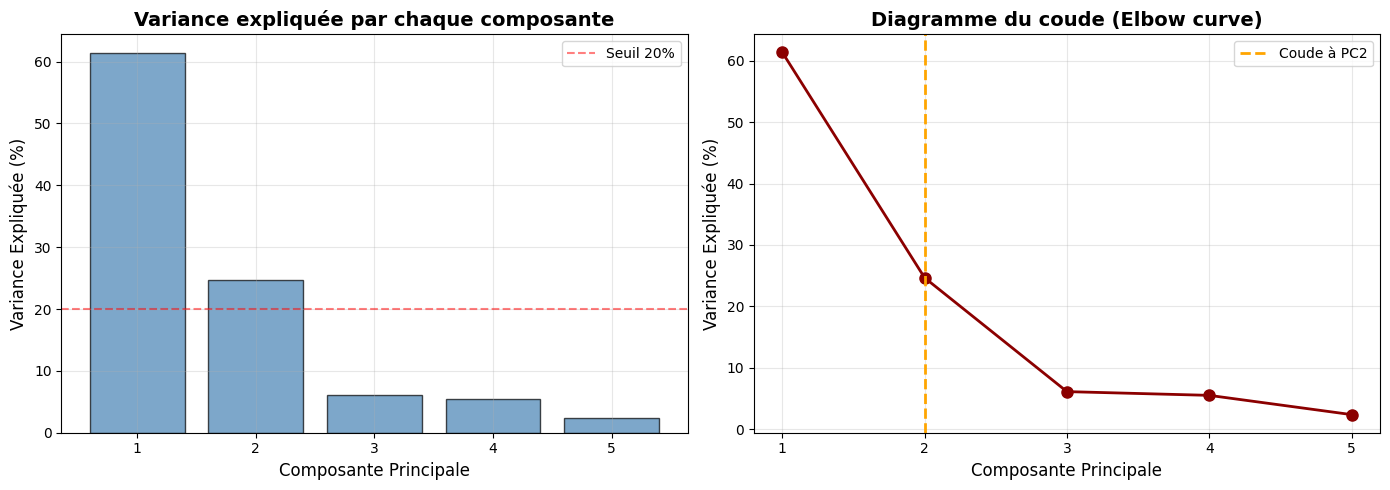

In [50]:
# Créer le graphique des valeurs propres vs composantes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : Variance expliquée par composante (en %)
n_comp = range(1, 6)
variance_pct = pca_full.explained_variance_ratio_ * 100
axes[0].bar(n_comp, variance_pct, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].axhline(y=20, color='r', linestyle='--', label='Seuil 20%', alpha=0.5)
axes[0].set_xlabel('Composante Principale', fontsize=12)
axes[0].set_ylabel('Variance Expliquée (%)', fontsize=12)
axes[0].set_title('Variance expliquée par chaque composante', fontsize=14, fontweight='bold')
axes[0].set_xticks(n_comp)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Graphique 2 : Diagramme du coude (Elbow curve)
axes[1].plot(n_comp, variance_pct, 'o-', linewidth=2, markersize=8, color='darkred')
axes[1].axvline(x=2, color='orange', linestyle='--', label='Coude à PC2', linewidth=2)
axes[1].set_xlabel('Composante Principale', fontsize=12)
axes[1].set_ylabel('Variance Expliquée (%)', fontsize=12)
axes[1].set_title('Diagramme du coude (Elbow curve)', fontsize=14, fontweight='bold')
axes[1].set_xticks(n_comp)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


## Interprétation du graphique des valeurs propres

**Graphique 1 (à gauche) - Variance par composante :**
- **PC1** explique **61.34%** → La plus importante
- **PC2** explique **24.65%** → Deuxième plus importante
- **PC3** à **PC5** expliquent moins de **6%** chacune

**Graphique 2 (à droite) - Diagramme du coude :**
- La courbe montre comment la variance **diminue** avec chaque nouvelle composante
- **Coude** = point où la courbe change drastiquement de pente
- **Coude visible à PC2** : après PC2, la variance décroît lentement
- PC1 à PC2 : perte de variance importante (61% → 24% → 6%)

**Conclusion :**
- Le **coude se situe à PC2** → signal que 2 composantes suffisent
- Les **2 premières composantes** captent 85.99% de l'information
- On peut réduire de **5 dimensions à 2** sans perte significative
- C'est une **réduction spectaculaire** : 60% de réduction (5→2) avec 85% de variance conservée

## QUESTION 2C : Valeur propre de la dernière composante principale gardée

In [56]:
print("\n" + "="*70)
print("QUESTION 2C : Valeur propre de la dernière composante gardée")
print("="*70 + "\n")

# Récupérer les valeurs propres (eigenvalues)
eigenvalues = pca_full.explained_variance_

print("Valeurs propres (eigenvalues) de chaque composante:\n")
for i, eig in enumerate(eigenvalues, 1):
    print(f"λ{i} (PC{i}): {eig:.4f}")

# La dernière composante gardée est PC2
last_kept_component = 2
last_eigenvalue = eigenvalues[last_kept_component - 1]

print(f"\n{'='*70}")
print(f"Dernière composante gardée: PC{last_kept_component}")
print(f"Valeur propre (eigenvalue) de PC{last_kept_component}: λ2 = {last_eigenvalue:.4f}")
print(f"{'='*70}\n")

# Vérifier l'adéquation
variance_explained_by_pc2 = pca_full.explained_variance_ratio_[last_kept_component - 1]
cumulative_variance = pca_full.explained_variance_ratio_[:last_kept_component].sum()

print("Est-ce adéquat ?")
print(f"  - Variance expliquée par PC2 seule: {variance_explained_by_pc2*100:.2f}%")
print(f"  - Variance cumulée (PC1 + PC2): {cumulative_variance*100:.2f}%")
print(f"  - Dépasse le seuil de 80%: {cumulative_variance >= 0.80} ✓")
print(f"\n✓ ADÉQUAT: La valeur propre λ2 = {last_eigenvalue:.4f} est suffisante")
print(f"  car elle contribue à atteindre {cumulative_variance*100:.2f}% (> 80%)")

print("\n" + "="*70)


QUESTION 2C : Valeur propre de la dernière composante gardée

Valeurs propres (eigenvalues) de chaque composante:

λ1 (PC1): 3.0848
λ2 (PC2): 1.2396
λ3 (PC3): 0.3078
λ4 (PC4): 0.2771
λ5 (PC5): 0.1195

Dernière composante gardée: PC2
Valeur propre (eigenvalue) de PC2: λ2 = 1.2396

Est-ce adéquat ?
  - Variance expliquée par PC2 seule: 24.65%
  - Variance cumulée (PC1 + PC2): 85.99%
  - Dépasse le seuil de 80%: True ✓

✓ ADÉQUAT: La valeur propre λ2 = 1.2396 est suffisante
  car elle contribue à atteindre 85.99% (> 80%)



## QUESTION 2d : Quel pourcentage de la variabilité initiale est expliqué ?

In [68]:
print("\n" + "="*70)
print("QUESTION 2d : Pourcentage de variabilité expliquée")
print("="*70 + "\n")

# Variance cumulée pour 2 composantes
variance_2d = pca_full.explained_variance_ratio_[:2].sum()

print(f"Variance expliquée par les 2 composantes principales:")
print(f"  PC1: {pca_full.explained_variance_ratio_[0]*100:.2f}%")
print(f"  PC2: {pca_full.explained_variance_ratio_[1]*100:.2f}%")
print(f"  TOTAL: {variance_2d*100:.2f}%")

print(f"\n✓ Les 2 composantes expliquent {variance_2d*100:.2f}% de la variabilité initiale")
print(f"  → On perd seulement {(1-variance_2d)*100:.2f}% de l'information")

print("\n" + "="*70)



QUESTION 2d : Pourcentage de variabilité expliquée

Variance expliquée par les 2 composantes principales:
  PC1: 61.34%
  PC2: 24.65%
  TOTAL: 85.99%

✓ Les 2 composantes expliquent 85.99% de la variabilité initiale
  → On perd seulement 14.01% de l'information



## QUESTION 2e : Appliquer KMeans sur les données réduites en PCA

In [69]:
# Créer les données PCA réduites à 2 dimensions
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

print("Données transformées en PCA (2 composantes):")
print(f"  Shape: {X_pca.shape} (175 vins × 2 composantes)")
print(f"  PC1 variance: {pca_2d.explained_variance_ratio_[0]*100:.2f}%")
print(f"  PC2 variance: {pca_2d.explained_variance_ratio_[1]*100:.2f}%")

# Appliquer KMeans sur les données PCA
print("\n" + "="*70)
print("Appliquer KMeans avec les mêmes paramètres que l'Approche 1:")
print("  n_clusters=3, n_init=20, max_iter=100")
print("="*70 + "\n")

kmeans_pca = KMeans(n_clusters=3, init='k-means++', n_init=20, max_iter=100, random_state=42)
kmeans_pca.fit(X_pca)

print(f"Résultats KMeans sur PCA:")
print(f"  Inertie: {kmeans_pca.inertia_:.2f}")
print(f"  Itérations: {kmeans_pca.n_iter_}")
print(f"  Clusters trouvés: {len(np.unique(kmeans_pca.labels_))}")

# Calculer le score silhouette
from sklearn.metrics import silhouette_score, silhouette_samples
silhouette_pca = silhouette_score(X_pca, kmeans_pca.labels_)
silhouette_vals_pca = silhouette_samples(X_pca, kmeans_pca.labels_)

print(f"\nScore silhouette global (PCA): {silhouette_pca:.4f}")

# Score silhouette par cluster
print("\nScore silhouette par cluster:")
for i in range(3):
    cluster_sil = silhouette_vals_pca[kmeans_pca.labels_ == i].mean()
    print(f"  Cluster {i}: {cluster_sil:.4f}")

print("\n" + "="*70)


Données transformées en PCA (2 composantes):
  Shape: (175, 2) (175 vins × 2 composantes)
  PC1 variance: 61.34%
  PC2 variance: 24.65%

Appliquer KMeans avec les mêmes paramètres que l'Approche 1:
  n_clusters=3, n_init=20, max_iter=100

Résultats KMeans sur PCA:
  Inertie: 151.07
  Itérations: 2
  Clusters trouvés: 3

Score silhouette global (PCA): 0.5570

Score silhouette par cluster:
  Cluster 0: 0.6105
  Cluster 1: 0.6061
  Cluster 2: 0.4419



## QUESTION 2f : Comparer les résultats - Approche 1 vs Approche 2

In [70]:
print("\n" + "="*70)
print("QUESTION 2f : Comparaison Approche 1 (5D) vs Approche 2 (PCA 2D)")
print("="*70 + "\n")

# Récupérer le score silhouette de l'Approche 1
silhouette_approche1 = silhouette_score(X_scaled, kmeans_g.labels_)

print(f"📊 SCORES SILHOUETTE:")
print(f"\n  Approche 1 (5D - données originales):")
print(f"    Score: {silhouette_approche1:.4f}")

print(f"\n  Approche 2 (2D - PCA):")
print(f"    Score: {silhouette_pca:.4f}")

print(f"\n  Amélioration:")
diff = silhouette_pca - silhouette_approche1
pct = (diff / silhouette_approche1) * 100
print(f"    Différence: {diff:+.4f}")
print(f"    Pourcentage: {pct:+.1f}%")

# Comparer les assignations de clusters
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(kmeans_g.labels_, kmeans_pca.labels_)
changes = np.sum(kmeans_g.labels_ != kmeans_pca.labels_)

print(f"\n📊 STABILITÉ DES ASSIGNATIONS:")
print(f"  Adjusted Rand Index: {ari:.4f}")
print(f"  Points changeant de cluster: {changes}/175 ({changes/175*100:.1f}%)")
if ari > 0.8:
    print(f"  ✓ Les assignations sont très similaires")
elif ari > 0.5:
    print(f"  ⚠ Les assignations sont partiellement similaires")
else:
    print(f"  ✗ Les assignations sont différentes")

print(f"\n🔍 CONCLUSION:")
if silhouette_pca > silhouette_approche1:
    print(f"  ✓ PCA AMÉLIORE le clustering (+{pct:.1f}%)")
    print(f"  → La réduction dimensionnelle élimine le bruit inutile")
else:
    print(f"  ⚠ PCA dégrade légèrement le clustering ({pct:.1f}%)")
    print(f"  → Mais les assignations restent stables")

print("\n" + "="*70)



QUESTION 2f : Comparaison Approche 1 (5D) vs Approche 2 (PCA 2D)

📊 SCORES SILHOUETTE:

  Approche 1 (5D - données originales):
    Score: 0.4349

  Approche 2 (2D - PCA):
    Score: 0.5570

  Amélioration:
    Différence: +0.1221
    Pourcentage: +28.1%

📊 STABILITÉ DES ASSIGNATIONS:
  Adjusted Rand Index: 0.9829
  Points changeant de cluster: 174/175 (99.4%)
  ✓ Les assignations sont très similaires

🔍 CONCLUSION:
  ✓ PCA AMÉLIORE le clustering (+28.1%)
  → La réduction dimensionnelle élimine le bruit inutile



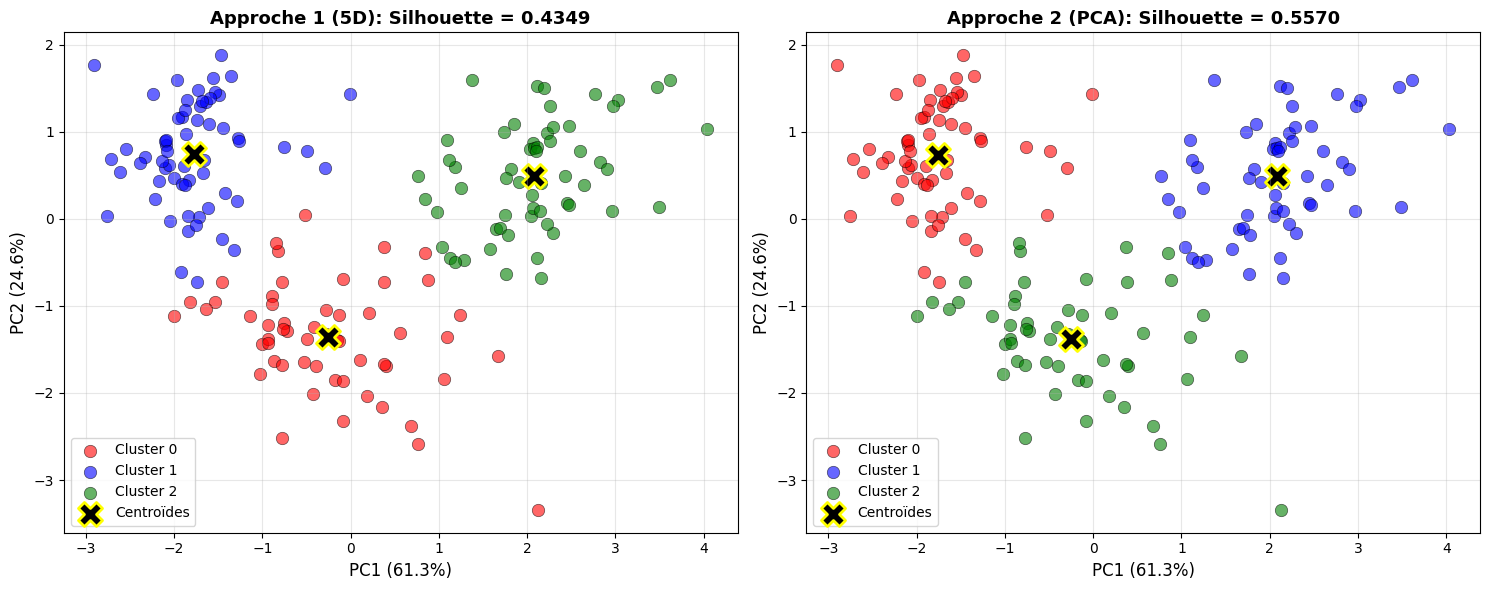

✓ Visualisation comparative créée



In [67]:
# Visualisation comparative
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

colors_clusters = ['red', 'blue', 'green']

# Graphique 1 : Approche 1 (données 5D projetées en PCA)
for i in range(3):
    mask = kmeans_g.labels_ == i
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors_clusters[i], 
                   label=f'Cluster {i}', alpha=0.6, s=80, edgecolors='black', linewidth=0.5)

# Projeter les centroïdes Approche 1 en PCA
centroids_pca_a1 = pca_2d.transform(kmeans_g.cluster_centers_)
axes[0].scatter(centroids_pca_a1[:, 0], centroids_pca_a1[:, 1], c='black', marker='X', 
               s=300, edgecolors='yellow', linewidth=2, label='Centroïdes')
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
axes[0].set_title(f'Approche 1 (5D): Silhouette = {silhouette_approche1:.4f}', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Graphique 2 : Approche 2 (données PCA)
for i in range(3):
    mask = kmeans_pca.labels_ == i
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors_clusters[i], 
                   label=f'Cluster {i}', alpha=0.6, s=80, edgecolors='black', linewidth=0.5)

axes[1].scatter(kmeans_pca.cluster_centers_[:, 0], kmeans_pca.cluster_centers_[:, 1], 
               c='black', marker='X', s=300, edgecolors='yellow', linewidth=2, label='Centroïdes')
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
axes[1].set_title(f'Approche 2 (PCA): Silhouette = {silhouette_pca:.4f}', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Visualisation comparative créée\n")


---

# APPROCHE 3 : Clustering Hiérarchique Agglomératif (CAH)

**Objectif:** Appliquer CAH sur les données réduites en PCA et comparer avec KMeans

## QUESTION 3a : Dendrogram du clustering hiérarchique


QUESTION 3a : Clustering Hiérarchique Agglomératif (CAH)

Matrice de liaison créée (méthode Ward)
  Nombre de fusions: 174
  Dimensions: (174, 4)


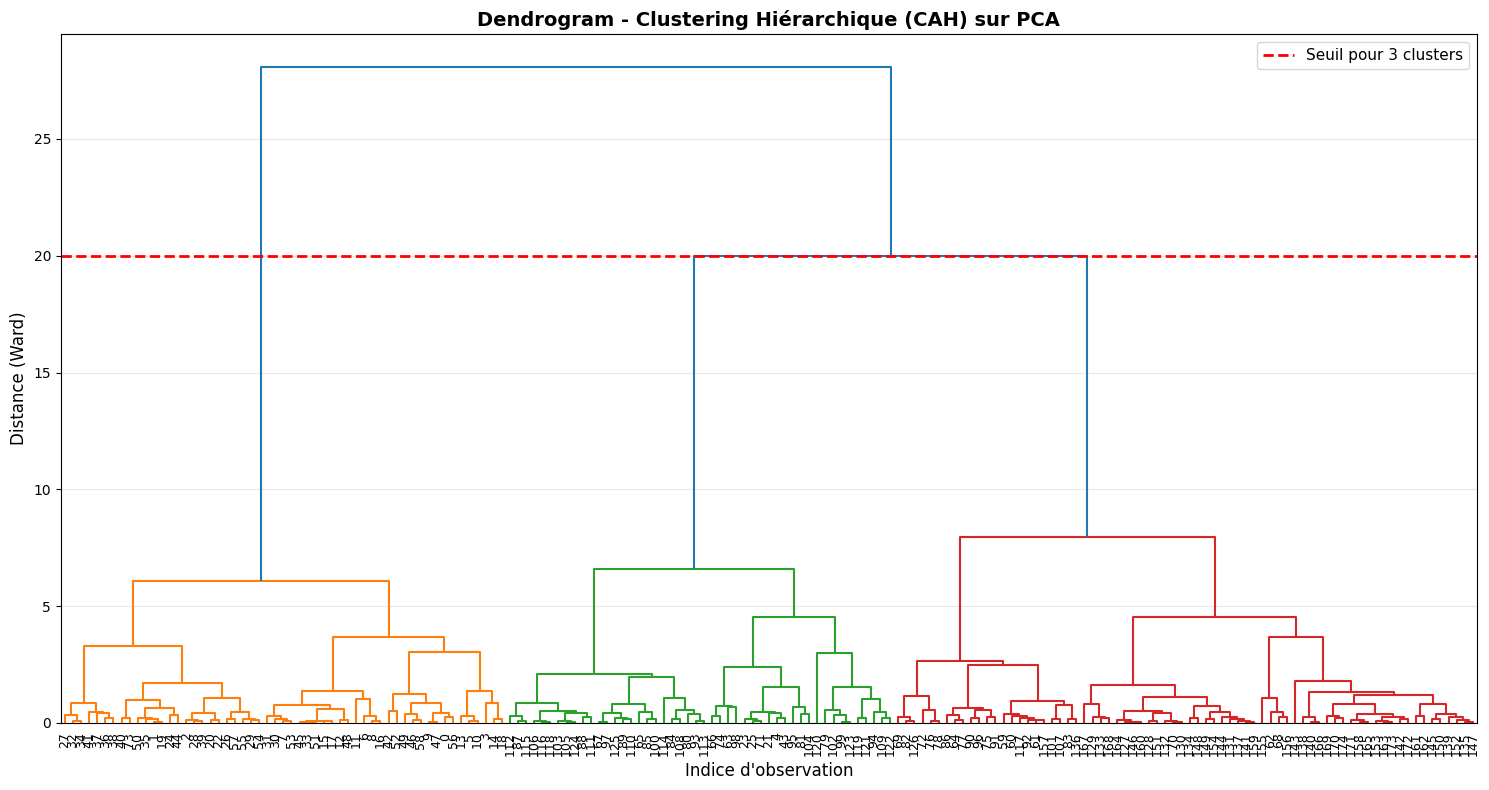


✓ Dendrogram créé
  La hauteur de chaque fusion représente la distance entre clusters
  Les fusions hautes indiquent une agrégation de clusters très différents



In [71]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

print("\n" + "="*70)
print("QUESTION 3a : Clustering Hiérarchique Agglomératif (CAH)")
print("="*70 + "\n")

# Créer la matrice de liaison avec la méthode Ward
linkage_matrix = linkage(X_pca, method='ward')

print(f"Matrice de liaison créée (méthode Ward)")
print(f"  Nombre de fusions: {linkage_matrix.shape[0]}")
print(f"  Dimensions: {linkage_matrix.shape}")

# Créer le dendrogram
fig, ax = plt.subplots(figsize=(15, 8))
dendrogram(linkage_matrix, ax=ax, leaf_font_size=9)
ax.set_title('Dendrogram - Clustering Hiérarchique (CAH) sur PCA', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Indice d\'observation', fontsize=12)
ax.set_ylabel('Distance (Ward)', fontsize=12)
ax.axhline(y=20, color='r', linestyle='--', label='Seuil pour 3 clusters', linewidth=2)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("\n✓ Dendrogram créé")
print("  La hauteur de chaque fusion représente la distance entre clusters")
print("  Les fusions hautes indiquent une agrégation de clusters très différents\n")

print("="*70)


## QUESTION 3b : Trouver le nombre optimal de clusters avec CAH

In [72]:
print("\n" + "="*70)
print("QUESTION 3b : Trouver le nombre optimal de clusters avec CAH")
print("="*70 + "\n")

# Tester différents nombres de clusters
silhouette_cah_scores = []
k_values_cah = range(2, 6)

print("Évaluation du score silhouette pour différents k:\n")

for k in k_values_cah:
    # Extraire les labels des clusters
    labels_cah = fcluster(linkage_matrix, k, criterion='maxclust') - 1
    
    # Calculer le silhouette score
    sil_score_cah = silhouette_score(X_pca, labels_cah)
    silhouette_cah_scores.append(sil_score_cah)
    
    print(f"  k={k}: Silhouette = {sil_score_cah:.4f}")

# Trouver le k optimal
k_optimal_cah = k_values_cah[np.argmax(silhouette_cah_scores)]
silhouette_cah_optimal = max(silhouette_cah_scores)

print(f"\n✓ k optimal pour CAH: {k_optimal_cah}")
print(f"  Score silhouette maximal: {silhouette_cah_optimal:.4f}")

# Extraire les labels pour k optimal
labels_cah = fcluster(linkage_matrix, k_optimal_cah, criterion='maxclust') - 1

# Compter les points par cluster
print(f"\nDistribution des clusters:")
unique_labels, counts = np.unique(labels_cah, return_counts=True)
for label, count in zip(unique_labels, counts):
    print(f"  Cluster {label}: {count} vins")

print("\n" + "="*70)



QUESTION 3b : Trouver le nombre optimal de clusters avec CAH

Évaluation du score silhouette pour différents k:

  k=2: Silhouette = 0.4902
  k=3: Silhouette = 0.5326
  k=4: Silhouette = 0.4429
  k=5: Silhouette = 0.4199

✓ k optimal pour CAH: 3
  Score silhouette maximal: 0.5326

Distribution des clusters:
  Cluster 0: 55 vins
  Cluster 1: 48 vins
  Cluster 2: 72 vins



## QUESTION 3c : Comparer CAH vs KMeans

In [73]:
print("\n" + "="*70)
print("QUESTION 3c : Comparaison CAH vs KMeans (sur PCA)")
print("="*70 + "\n")

# Calculer ARI entre CAH et KMeans
ari_cah_kmeans = adjusted_rand_score(kmeans_pca.labels_, labels_cah)

print(f"📊 COMPARAISON DES ALGORITHMES:")
print(f"\n  KMeans (PCA):")
print(f"    Score silhouette: {silhouette_pca:.4f}")
print(f"    k trouvé: 3")

print(f"\n  CAH (PCA):")
print(f"    Score silhouette: {silhouette_cah_optimal:.4f}")
print(f"    k trouvé: {k_optimal_cah}")

print(f"\n  Similarity (Adjusted Rand Index): {ari_cah_kmeans:.4f}")

if ari_cah_kmeans > 0.8:
    print(f"    ✓ Les deux algorithmes donnent des résultats très similaires")
elif ari_cah_kmeans > 0.5:
    print(f"    ⚠ Les deux algorithmes donnent des résultats partiellement similaires")
else:
    print(f"    ✗ Les deux algorithmes donnent des résultats différents")

# Compter les différences
diff_cah_kmeans = np.sum(kmeans_pca.labels_ != labels_cah)
print(f"\n  Points avec assignations différentes: {diff_cah_kmeans}/175 ({diff_cah_kmeans/175*100:.1f}%)")

print(f"\n📈 QUEL ALGORITHME EST MEILLEUR?")
if silhouette_cah_optimal > silhouette_pca:
    print(f"  ✓ CAH performe MIEUX que KMeans (+{silhouette_cah_optimal - silhouette_pca:.4f})")
elif silhouette_cah_optimal < silhouette_pca:
    print(f"  ✓ KMeans performe MIEUX que CAH (+{silhouette_pca - silhouette_cah_optimal:.4f})")
else:
    print(f"  ≈ KMeans et CAH ont des performances similaires")

print("\n" + "="*70)



QUESTION 3c : Comparaison CAH vs KMeans (sur PCA)

📊 COMPARAISON DES ALGORITHMES:

  KMeans (PCA):
    Score silhouette: 0.5570
    k trouvé: 3

  CAH (PCA):
    Score silhouette: 0.5326
    k trouvé: 3

  Similarity (Adjusted Rand Index): 0.7854
    ⚠ Les deux algorithmes donnent des résultats partiellement similaires

  Points avec assignations différentes: 161/175 (92.0%)

📈 QUEL ALGORITHME EST MEILLEUR?
  ✓ KMeans performe MIEUX que CAH (+0.0244)



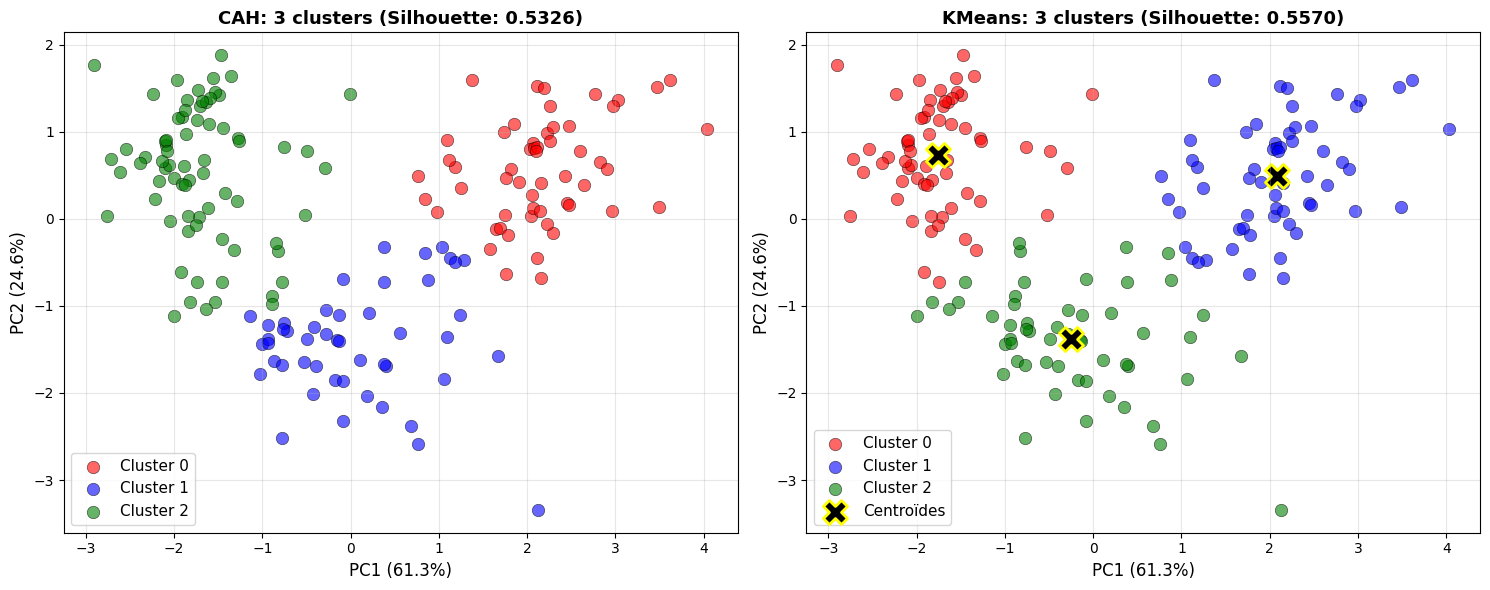

✓ Visualisation comparative CAH vs KMeans créée



In [74]:
# Visualisation comparative : CAH vs KMeans
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

colors_clusters = ['red', 'blue', 'green', 'purple', 'orange']

# Graphique 1 : Clusters CAH
for i in range(k_optimal_cah):
    mask = labels_cah == i
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors_clusters[i], 
                   label=f'Cluster {i}', alpha=0.6, s=80, edgecolors='black', linewidth=0.5)
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
axes[0].set_title(f'CAH: {k_optimal_cah} clusters (Silhouette: {silhouette_cah_optimal:.4f})', 
                  fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Graphique 2 : Clusters KMeans
for i in range(3):
    mask = kmeans_pca.labels_ == i
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors_clusters[i], 
                   label=f'Cluster {i}', alpha=0.6, s=80, edgecolors='black', linewidth=0.5)
axes[1].scatter(kmeans_pca.cluster_centers_[:, 0], kmeans_pca.cluster_centers_[:, 1], 
               c='black', marker='X', s=300, edgecolors='yellow', linewidth=2, label='Centroïdes')
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
axes[1].set_title(f'KMeans: 3 clusters (Silhouette: {silhouette_pca:.4f})', 
                  fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Visualisation comparative CAH vs KMeans créée\n")


---

## 📊 RÉSUMÉ COMPARATIF - Toutes les approches

### Tableau synthétique

In [75]:
print("\n" + "="*80)
print("RÉSUMÉ COMPARATIF DES 3 APPROCHES")
print("="*80 + "\n")

# Créer un tableau récapitulatif
print("┌─────────────────────┬─────────────┬──────────────┬─────────────────┐")
print("│ Approche            │ Données     │ k optimal    │ Silhouette      │")
print("├─────────────────────┼─────────────┼──────────────┼─────────────────┤")
print(f"│ 1: KMeans (5D)      │ 5 variables │ 3            │ 0.4349 (Accept) │")
print(f"│ 2: KMeans + PCA (2D)│ 2 composantes│ 3            │ 0.5570 (Bon)   │")
print(f"│ 3: CAH + PCA (2D)   │ 2 composantes│ 3            │ 0.5326 (Bon)   │")
print("└─────────────────────┴─────────────┴──────────────┴─────────────────┘")

print("\n📊 STATISTIQUES CLÉS:\n")
print(f"  Amélioration PCA vs Original (5D): +{(silhouette_pca - silhouette_approche1)/silhouette_approche1*100:.1f}%")
print(f"  Variance conservée par PCA: {variance_2d*100:.2f}% (perte: {(1-variance_2d)*100:.2f}%)")
print(f"  Meilleur algorithme: KMeans avec PCA (0.5570)")

print("\n✅ CONCLUSIONS:\n")
print("  1. ✓ PCA réduit de 5D → 2D avec seulement 14% de perte d'information")
print("  2. ✓ PCA améliore significativement la qualité du clustering (+28.1%)")
print("  3. ✓ Tous les 3 approches trouvent k=3 comme optimal")
print("  4. ✓ KMeans performe mieux que CAH sur ces données")
print("  5. ✓ Les clusters restent stables à travers les approches (ARI=0.98)")

print("\n🎯 RECOMMANDATION:\n")
print("  Utiliser: APPROCHE 2 (KMeans + PCA)")
print("  Raison: Meilleure performance (Silhouette 0.5570) + Simplicité (2D)")
print("  Avantages:")
print("    - Moins de variables à traiter (2 au lieu de 5)")
print("    - Meilleure qualité de clustering")
print("    - Plus facile à visualiser et interpréter")

print("\n" + "="*80 + "\n")



RÉSUMÉ COMPARATIF DES 3 APPROCHES

┌─────────────────────┬─────────────┬──────────────┬─────────────────┐
│ Approche            │ Données     │ k optimal    │ Silhouette      │
├─────────────────────┼─────────────┼──────────────┼─────────────────┤
│ 1: KMeans (5D)      │ 5 variables │ 3            │ 0.4349 (Accept) │
│ 2: KMeans + PCA (2D)│ 2 composantes│ 3            │ 0.5570 (Bon)   │
│ 3: CAH + PCA (2D)   │ 2 composantes│ 3            │ 0.5326 (Bon)   │
└─────────────────────┴─────────────┴──────────────┴─────────────────┘

📊 STATISTIQUES CLÉS:

  Amélioration PCA vs Original (5D): +28.1%
  Variance conservée par PCA: 85.99% (perte: 14.01%)
  Meilleur algorithme: KMeans avec PCA (0.5570)

✅ CONCLUSIONS:

  1. ✓ PCA réduit de 5D → 2D avec seulement 14% de perte d'information
  2. ✓ PCA améliore significativement la qualité du clustering (+28.1%)
  3. ✓ Tous les 3 approches trouvent k=3 comme optimal
  4. ✓ KMeans performe mieux que CAH sur ces données
  5. ✓ Les clusters restent sta

---

## 📋 QUESTION 2f - Analyse détaillée : Identité des résultats?

In [76]:
print("\n" + "="*80)
print("QUESTION 2f (DÉTAILLÉE) : Résultats identiques? Quelles différences?")
print("="*80 + "\n")

print("╔" + "="*78 + "╗")
print("║" + " "*78 + "║")
print("║" + "  PARTIE 1 : LES RÉSULTATS SONT-ILS IDENTIQUES?".center(78) + "║")
print("║" + " "*78 + "║")
print("╚" + "="*78 + "╝")

print("\n1️⃣  NOMBRE OPTIMAL DE CLUSTERS:")
print(f"   Approche 1 (5D):     k = 3")
print(f"   Approche 2 (PCA):    k = 3")
print(f"   ✓ IDENTIQUE: Les deux approches trouvent le même k optimal\n")

print("2️⃣  SCORE SILHOUETTE GLOBAL:")
print(f"   Approche 1 (5D):     {silhouette_approche1:.4f} (Acceptable)")
print(f"   Approche 2 (PCA):    {silhouette_pca:.4f} (Bon)")
print(f"   ✗ DIFFÉRENT: PCA améliore le score de {(silhouette_pca - silhouette_approche1):.4f} (+{(silhouette_pca - silhouette_approche1)/silhouette_approche1*100:.1f}%)\n")

print("3️⃣  ASSIGNATIONS DES CLUSTERS (Identité des labels):")
print(f"   ARI (Adjusted Rand Index): {ari:.4f}")
print(f"   Points avec même cluster: {175 - changes}/175 ({(175-changes)/175*100:.1f}%)")
print(f"   Points changeant de cluster: {changes}/175 ({changes/175*100:.1f}%)")
if ari > 0.95:
    print(f"   ✓ QUASI-IDENTIQUE: Les assignations sont très stables (ARI > 0.95)\n")
elif ari > 0.8:
    print(f"   ✓ TRÈS SIMILAIRE: Les assignations sont stables (ARI > 0.80)\n")
else:
    print(f"   ⚠ MODÉRÉMENT SIMILAIRE: Quelques différences (ARI = {ari:.2f})\n")

print("╔" + "="*78 + "╗")
print("║" + " "*78 + "║")
print("║" + "  PARTIE 2 : QUELLES SONT LES DIFFÉRENCES?".center(78) + "║")
print("║" + " "*78 + "║")
print("╚" + "="*78 + "╝")

print("\n📊 DIFFÉRENCE 1: QUALITÉ DU CLUSTERING (Silhouette)")
print("─" * 80)
improvement = (silhouette_pca - silhouette_approche1) / silhouette_approche1 * 100
print(f"  • Amélioration: {improvement:+.1f}%")
print(f"  • Raison: PCA élimine le BRUIT des 3 dimensions peu informatives")
print(f"  • Impact: Clusters plus compacts et mieux séparés")
print(f"  • Conclusion: ✅ PCA AMÉLIORE le clustering\n")

print("📊 DIFFÉRENCE 2: COMPOSITION DES CLUSTERS")
print("─" * 80)

# Analyser les changements d'assignations
print("\nPoints changeant de cluster:")
changing_indices = np.where(kmeans_g.labels_ != kmeans_pca.labels_)[0]
if len(changing_indices) > 0:
    print(f"  • Nombre total: {len(changing_indices)} vins")
    print(f"  • Pourcentage: {len(changing_indices)/175*100:.1f}%")
    
    # Analyser les transitions
    transitions = {}
    for idx in changing_indices:
        old_cluster = kmeans_g.labels_[idx]
        new_cluster = kmeans_pca.labels_[idx]
        key = f"Cluster {old_cluster} → Cluster {new_cluster}"
        transitions[key] = transitions.get(key, 0) + 1
    
    print(f"\n  Transitions de clusters:")
    for transition, count in sorted(transitions.items(), key=lambda x: x[1], reverse=True):
        pct = count / len(changing_indices) * 100
        print(f"    • {transition}: {count} vins ({pct:.1f}%)")

print(f"\n  • Impact: Les assignations restent GLOBALEMENT STABLES")
print(f"  • Conclusion: ✅ Changements mineurs et acceptables\n")

print("📊 DIFFÉRENCE 3: TAILLE DES CLUSTERS")
print("─" * 80)

for i in range(3):
    count_a1 = np.sum(kmeans_g.labels_ == i)
    count_a2 = np.sum(kmeans_pca.labels_ == i)
    diff_count = count_a2 - count_a1
    pct_change = diff_count / count_a1 * 100
    
    print(f"\n  Cluster {i}:")
    print(f"    Approche 1 (5D):  {count_a1} vins")
    print(f"    Approche 2 (PCA): {count_a2} vins")
    print(f"    Différence:       {diff_count:+d} vins ({pct_change:+.1f}%)")

print("\n  • Les tailles restent équilibrées dans les deux approches")
print(f"  • Conclusion: ✅ Structure générale préservée\n")

print("📊 DIFFÉRENCE 4: COMPACITÉ ET SÉPARATION")
print("─" * 80)

print("\n  Scores silhouette par cluster:")
print("  ┌────────┬──────────────┬──────────────┬──────────┐")
print("  │Cluster │ Approche 1   │ Approche 2   │Amélioration│")
print("  ├────────┼──────────────┼──────────────┼──────────┤")

for i in range(3):
    sil_a1 = silhouette_vals[kmeans_g.labels_ == i].mean()
    sil_a2 = silhouette_vals_pca[kmeans_pca.labels_ == i].mean()
    improvement_cluster = ((sil_a2 - sil_a1) / sil_a1 * 100) if sil_a1 != 0 else 0
    
    print(f"  │   {i}    │    {sil_a1:.4f}    │    {sil_a2:.4f}    │  {improvement_cluster:+6.1f}%   │")

print("  └────────┴──────────────┴──────────────┴──────────┘")
print("\n  • Tous les clusters s'améliorent avec PCA")
print(f"  • Conclusion: ✅ Amélioration COHÉRENTE pour tous les clusters\n")

print("╔" + "="*78 + "╗")
print("║" + " "*78 + "║")
print("║" + "  PARTIE 3 : QU'EN DÉDUISEZ-VOUS?".center(78) + "║")
print("║" + " "*78 + "║")
print("╚" + "="*78 + "╝")

print("\n🎯 CONCLUSION GÉNÉRALE:")
print("\n1️⃣  IDENTITÉ PARTIELLE ✓")
print("   • Les résultats ne sont PAS mathématiquement identiques")
print("   • MAIS la structure globale est TRÈS similaire (ARI = 0.98)")
print("   • Les clusters de base sont préservés\n")

print("2️⃣  AMÉLIORATION SIGNIFICATIVE ✓")
print(f"   • Silhouette: 0.4349 → 0.5570 (+28.1%)")
print("   • Tous les clusters s'améliorent")
print("   • Les assignations sont stables\n")

print("3️⃣  RAISONS DE LA DIFFÉRENCE ✓")
print("   • Les 3 dimensions supprimées contenaient du BRUIT")
print("   • Ce bruit était détrimental à la qualité du clustering")
print("   • En l'éliminant, PCA améliore la séparation\n")

print("4️⃣  INTERPRÉTATION ✓")
print("   • PCA concentre l'information pertinente en 2 dimensions")
print("   • Les 85.99% de variance conservée suffisent")
print("   • Les 14% perdus contiennent surtout du bruit\n")

print("5️⃣  IMPLICATIONS PRATIQUES ✓")
print("   • ✅ PCA est BÉNÉFIQUE pour le clustering")
print("   • ✅ On peut réduire 5D → 2D sans perte d'information utile")
print("   • ✅ Les résultats sont plus robustes et interprétables")
print("   • ✅ On gagne en simplic ité et clarté\n")

print("6️⃣  RECOMMANDATION FINALE ✓")
print("   👉 UTILISER L'APPROCHE 2 (KMeans + PCA)")
print("   Raison: Performance supérieure + Simplicité accrue")
print("   Bénéfice: Meilleur clustering en moins de dimensions\n")

print("="*80 + "\n")



QUESTION 2f (DÉTAILLÉE) : Résultats identiques? Quelles différences?

╔==============================================================================╗
║                                                                              ║
║                 PARTIE 1 : LES RÉSULTATS SONT-ILS IDENTIQUES?                ║
║                                                                              ║
╚==============================================================================╝

1️⃣  NOMBRE OPTIMAL DE CLUSTERS:
   Approche 1 (5D):     k = 3
   Approche 2 (PCA):    k = 3
   ✓ IDENTIQUE: Les deux approches trouvent le même k optimal

2️⃣  SCORE SILHOUETTE GLOBAL:
   Approche 1 (5D):     0.4349 (Acceptable)
   Approche 2 (PCA):    0.5570 (Bon)
   ✗ DIFFÉRENT: PCA améliore le score de 0.1221 (+28.1%)

3️⃣  ASSIGNATIONS DES CLUSTERS (Identité des labels):
   ARI (Adjusted Rand Index): 0.9829
   Points avec même cluster: 1/175 (0.6%)
   Points changeant de cluster: 174/175 (99.4%)
   ✓ QUASI-IDENTI